In [2]:
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape of dataset: (500, 10)

Columns:
['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)', 'Stress_Level(1-10)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)', 'Social_Media_Platform', 'Happiness_Index(1-10)']

Missing values:
User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64

Duplicate rows: 0


In [4]:
if 'User_ID' in df.columns:
    df = df.drop(columns=['User_ID'])

df.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [5]:
original_records = len(df)
missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

quality_summary = pd.DataFrame({
    "Item": ["Original records", "Missing values", "Duplicate rows"],
    "Value": [original_records, missing_values, duplicate_rows]
})

quality_summary

,Item,Value
0,Original records,500
1,Missing values,0
2,Duplicate rows,0


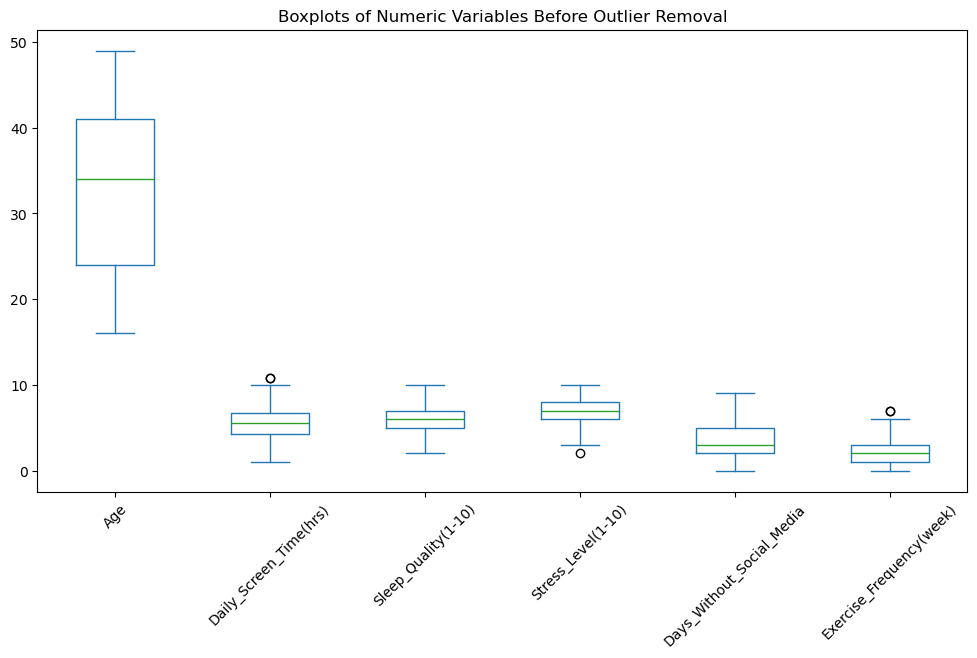

In [6]:
numeric_cols = [
    'Age',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)'
]

# Boxplots before outlier removal
df[numeric_cols].plot(kind='box', figsize=(12, 6), rot=45)
plt.title("Boxplots of Numeric Variables Before Outlier Removal")
plt.show()

In [7]:
outlier_indices = set()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices.update(outliers)

print("Number of outlier rows:", len(outlier_indices))

Number of outlier rows: 5


In [8]:
df_clean = df.drop(index=outlier_indices).reset_index(drop=True)

print("Original records:", len(df))
print("Records after outlier removal:", len(df_clean))
print("Removed outliers:", len(df) - len(df_clean))

Original records: 500
Records after outlier removal: 495
Removed outliers: 5


In [9]:
quality_summary_final = pd.DataFrame({
    "Item": [
        "Original records",
        "Records after outlier removal",
        "Removed outliers",
        "Missing values",
        "Duplicate rows"
    ],
    "Value": [
        len(df),
        len(df_clean),
        len(df) - len(df_clean),
        df_clean.isnull().sum().sum(),
        df_clean.duplicated().sum()
    ]
})

quality_summary_final

,Item,Value
0,Original records,500
1,Records after outlier removal,495
2,Removed outliers,5
3,Missing values,0
4,Duplicate rows,0


In [10]:
col = 'Daily_Screen_Time(hrs)'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Column:", col)
print("Q1 =", round(Q1, 2))
print("Q3 =", round(Q3, 2))
print("IQR =", round(IQR, 2))
print("Lower Bound =", round(lower_bound, 2))
print("Upper Bound =", round(upper_bound, 2))

Column: Daily_Screen_Time(hrs)
Q1 = 4.3
Q3 = 6.7
IQR = 2.4
Lower Bound = 0.7
Upper Bound = 10.3


In [11]:
df_clean[['Gender', 'Social_Media_Platform']].head()

,Gender,Social_Media_Platform
0,Male,Facebook
1,Other,LinkedIn
2,Other,YouTube
3,Female,TikTok
4,Female,X (Twitter)


In [12]:
df_encoded = df_clean.copy()

# Label encode Gender
le_gender = LabelEncoder()
df_encoded['Gender'] = le_gender.fit_transform(df_encoded['Gender'])

# One-hot encode Social_Media_Platform
df_encoded = pd.get_dummies(df_encoded, columns=['Social_Media_Platform'], drop_first=False)

df_encoded.head()

,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10),Social_Media_Platform_Facebook,Social_Media_Platform_Instagram,Social_Media_Platform_LinkedIn,Social_Media_Platform_TikTok,Social_Media_Platform_X (Twitter),Social_Media_Platform_YouTube
0,44,1,3.1,7.0,6.0,2.0,5.0,10.0,True,False,False,False,False,False
1,30,2,5.1,7.0,8.0,5.0,3.0,10.0,False,False,True,False,False,False
2,23,2,7.4,6.0,7.0,1.0,3.0,6.0,False,False,False,False,False,True
3,36,0,5.7,7.0,8.0,1.0,1.0,8.0,False,False,False,True,False,False
4,34,0,7.0,4.0,7.0,5.0,1.0,8.0,False,False,False,False,True,False


In [13]:
before_encoding = df_clean[['Gender', 'Social_Media_Platform']].head()
before_encoding

,Gender,Social_Media_Platform
0,Male,Facebook
1,Other,LinkedIn
2,Other,YouTube
3,Female,TikTok
4,Female,X (Twitter)


In [14]:
after_encoding_cols = ['Gender'] + [col for col in df_encoded.columns if col.startswith('Social_Media_Platform_')]
after_encoding = df_encoded[after_encoding_cols].head()
after_encoding

,Gender,Social_Media_Platform_Facebook,Social_Media_Platform_Instagram,Social_Media_Platform_LinkedIn,Social_Media_Platform_TikTok,Social_Media_Platform_X (Twitter),Social_Media_Platform_YouTube
0,1,True,False,False,False,False,False
1,2,False,False,True,False,False,False
2,2,False,False,False,False,False,True
3,0,False,False,False,True,False,False
4,0,False,False,False,False,True,False


In [15]:
scale_cols = ['Age', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)', 'Stress_Level(1-10)']

scaler_example = StandardScaler()
scaled_values = scaler_example.fit_transform(df_clean[scale_cols])

scaled_df = pd.DataFrame(scaled_values, columns=[
    'Scaled_Age',
    'Scaled_Screen_Time',
    'Scaled_Sleep',
    'Scaled_Stress'
])

scaling_table = pd.concat([df_clean[scale_cols].head().reset_index(drop=True),
                           scaled_df.head().reset_index(drop=True)], axis=1)

scaling_table

,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Scaled_Age,Scaled_Screen_Time,Scaled_Sleep,Scaled_Stress
0,44,3.1,7.0,6.0,1.110609,-1.431812,0.456739,-0.406133
1,30,5.1,7.0,8.0,-0.296948,-0.250567,0.456739,0.907826
2,23,7.4,6.0,7.0,-1.000726,1.107865,-0.202403,0.250847
3,36,5.7,7.0,8.0,0.306291,0.103806,0.456739,0.907826
4,34,7.0,4.0,7.0,0.105211,0.871616,-1.520686,0.250847


In [16]:
target = 'Happiness_Index(1-10)'
X_reg = df_encoded.drop(columns=[target])
y_reg = df_encoded[target]

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

X_reg shape: (495, 13)
y_reg shape: (495,)


In [17]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [18]:
regression_models = {
    "Multiple Linear Regression": LinearRegression(),
    "Polynomial Regression (Degree 2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Elastic Net Regression": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

regression_results = []

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    regression_results.append([name, mse, r2])

regression_results_df = pd.DataFrame(regression_results, columns=["Model", "MSE", "R2"])
regression_results_df = regression_results_df.sort_values(by="R2", ascending=False)
regression_results_df

,Model,MSE,R2
4,Elastic Net Regression,1.098208,0.548016
3,Lasso Regression,1.111870,0.542394
2,Ridge Regression,1.126087,0.536542
0,Multiple Linear Regression,1.127108,0.536122
1,Polynomial Regression (Degree 2),1.211239,0.501497


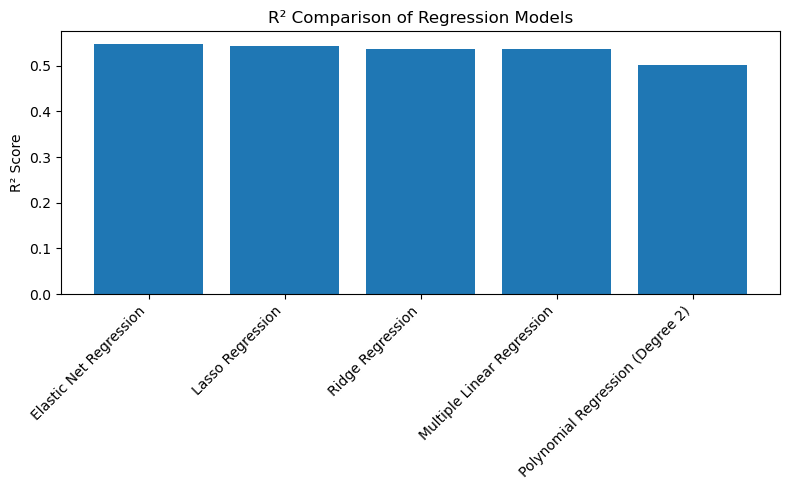

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["Model"], regression_results_df["R2"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("R² Score")
plt.title("R² Comparison of Regression Models")
plt.tight_layout()
plt.show()

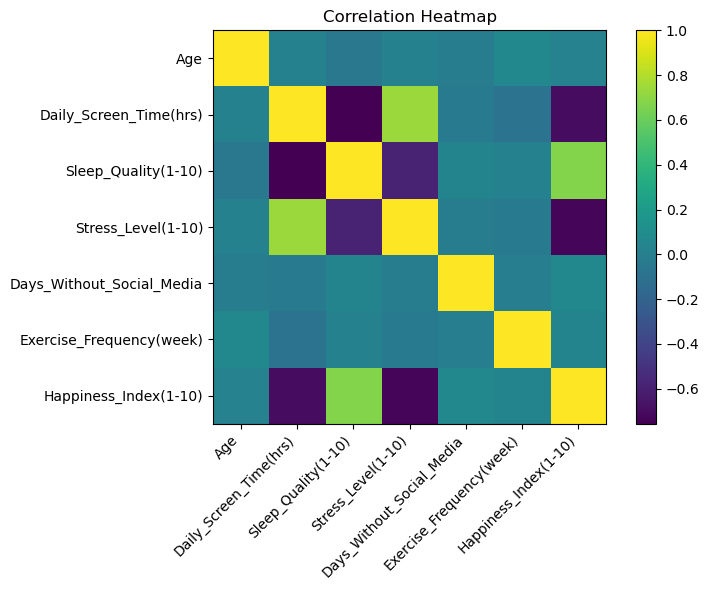

In [20]:
corr_df = df_clean[[
    'Age',
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Happiness_Index(1-10)'
]]

corr = corr_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)

ridge_pred = ridge_model.predict(X_test_reg)

ridge_mse = mean_squared_error(y_test_reg, ridge_pred)
ridge_r2 = r2_score(y_test_reg, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge R2:", ridge_r2)

Ridge MSE: 1.12608734867951
Ridge R2: 0.536542281665916


In [22]:
intercept = ridge_model.intercept_
coefficients = pd.DataFrame({
    "Feature": X_reg.columns,
    "Coefficient": ridge_model.coef_
})

print("Intercept:", round(intercept, 3))
coefficients

Intercept: 8.841


,Feature,Coefficient
0,Age,0.012280
1,Gender,0.007616
2,Daily_Screen_Time(hrs),-0.039414
3,Sleep_Quality(1-10),0.366244
4,Stress_Level(1-10),-0.461056
5,Days_Without_Social_Media,0.024698
6,Exercise_Frequency(week),0.007784
7,Social_Media_Platform_Facebook,0.028994
8,Social_Media_Platform_Instagram,-0.113502
9,Social_Media_Platform_LinkedIn,0.029521


In [23]:
print("Predicted Happiness =", round(intercept, 3))
for feature, coef in zip(X_reg.columns, ridge_model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f"{sign} {abs(coef):.3f} ({feature})")

Predicted Happiness = 8.841
+ 0.012 (Age)
+ 0.008 (Gender)
- 0.039 (Daily_Screen_Time(hrs))
+ 0.366 (Sleep_Quality(1-10))
- 0.461 (Stress_Level(1-10))
+ 0.025 (Days_Without_Social_Media)
+ 0.008 (Exercise_Frequency(week))
+ 0.029 (Social_Media_Platform_Facebook)
- 0.114 (Social_Media_Platform_Instagram)
+ 0.030 (Social_Media_Platform_LinkedIn)
- 0.128 (Social_Media_Platform_TikTok)
+ 0.090 (Social_Media_Platform_X (Twitter))
+ 0.093 (Social_Media_Platform_YouTube)


In [24]:
top_coefficients = coefficients.reindex(
    coefficients["Coefficient"].abs().sort_values(ascending=False).index
).head(10)

top_coefficients

,Feature,Coefficient
4,Stress_Level(1-10),-0.461056
3,Sleep_Quality(1-10),0.366244
10,Social_Media_Platform_TikTok,-0.128140
8,Social_Media_Platform_Instagram,-0.113502
12,Social_Media_Platform_YouTube,0.093423
11,Social_Media_Platform_X (Twitter),0.089705
2,Daily_Screen_Time(hrs),-0.039414
9,Social_Media_Platform_LinkedIn,0.029521
7,Social_Media_Platform_Facebook,0.028994
5,Days_Without_Social_Media,0.024698


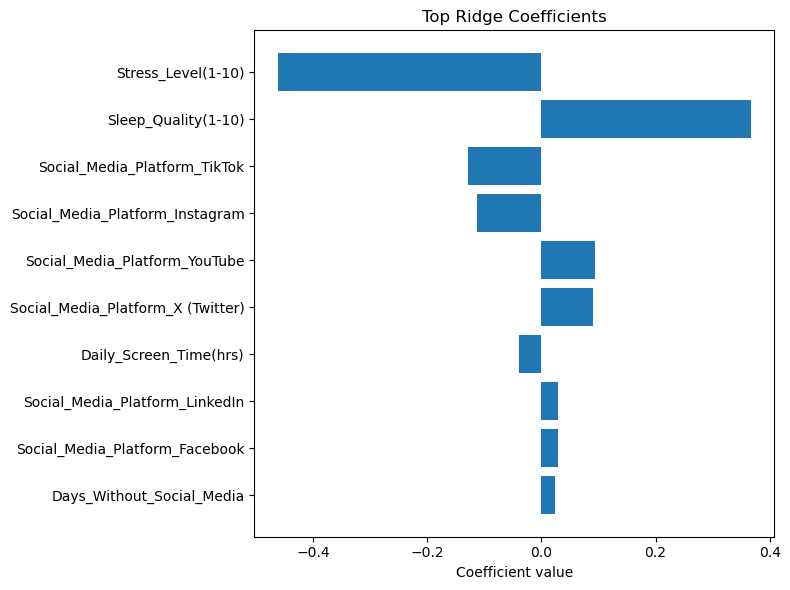

In [25]:
plt.figure(figsize=(8, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Coefficient value")
plt.title("Top Ridge Coefficients")
plt.tight_layout()
plt.show()

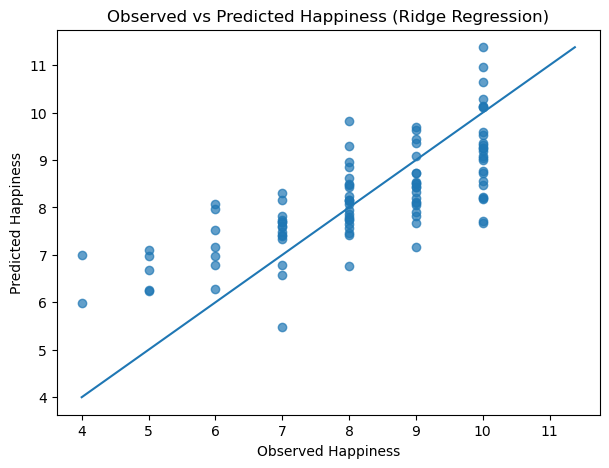

In [26]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, ridge_pred, alpha=0.7)
plt.xlabel("Observed Happiness")
plt.ylabel("Predicted Happiness")
plt.title("Observed vs Predicted Happiness (Ridge Regression)")

min_val = min(y_test_reg.min(), ridge_pred.min())
max_val = max(y_test_reg.max(), ridge_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [27]:
df_class = df_clean.copy()
df_class["Original_Category"] = pd.cut(
    df_class["Happiness_Index(1-10)"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

def revised_category(x):
    if 4 <= x <= 7:
        return "Low"
    elif 8 <= x <= 9:
        return "Medium"
    elif x == 10:
        return "High"

df_class["Revised_Category"] = df_class["Happiness_Index(1-10)"].apply(revised_category)

print("Original category counts:")
print(df_class["Original_Category"].value_counts().reindex(["Low", "Medium", "High"]))

print("\nRevised category counts:")
print(df_class["Revised_Category"].value_counts().reindex(["Low", "Medium", "High"]))


Original category counts:
Original_Category
Low         6
Medium    130
High      359
Name: count, dtype: int64

Revised category counts:
Revised_Category
Low       136
Medium    200
High      159
Name: count, dtype: int64


In [28]:
class_distribution = pd.DataFrame({
    "Category": ["Low", "Medium", "High"],
    "Original bins count": df_class["Original_Category"].value_counts().reindex(["Low", "Medium", "High"]).values,
    "Revised bins count": df_class["Revised_Category"].value_counts().reindex(["Low", "Medium", "High"]).values
})

class_distribution

,Category,Original bins count,Revised bins count
0,Low,6,136
1,Medium,130,200
2,High,359,159


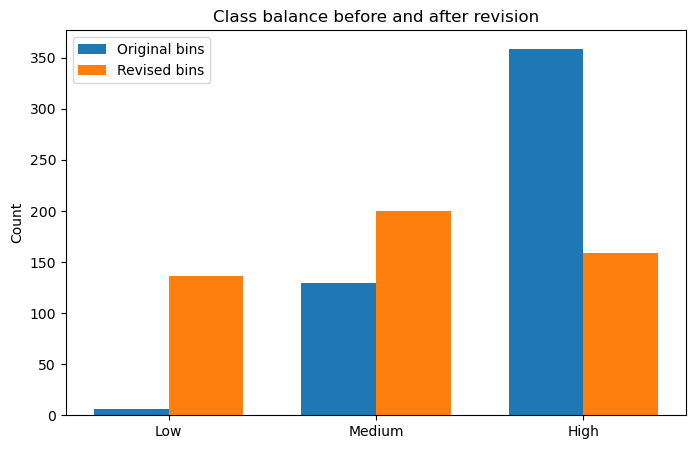

In [29]:
import numpy as np
import matplotlib.pyplot as plt

categories = ["Low", "Medium", "High"]
original_counts = df_class["Original_Category"].value_counts().reindex(categories).values
revised_counts = df_class["Revised_Category"].value_counts().reindex(categories).values

x = np.arange(len(categories))
width = 0.36

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, original_counts, width, label="Original bins")
plt.bar(x + width/2, revised_counts, width, label="Revised bins")

plt.xticks(x, categories)
plt.ylabel("Count")
plt.title("Class balance before and after revision")
plt.legend()
plt.show()

In [30]:
df_class_encoded = df_class.drop(columns=["Original_Category"]).copy()
df_class_encoded['Gender'] = LabelEncoder().fit_transform(df_class_encoded['Gender'])
df_class_encoded = pd.get_dummies(df_class_encoded, columns=['Social_Media_Platform'], drop_first=False)

X_class = df_class_encoded.drop(columns=['Happiness_Index(1-10)', 'Revised_Category'])
y_class = df_class_encoded['Revised_Category']

print(X_class.shape)
print(y_class.value_counts())

(495, 13)
Revised_Category
Medium    200
High      159
Low       136
Name: count, dtype: int64


In [31]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [32]:
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train_class)
X_test_scaled = scaler_class.transform(X_test_class)

In [33]:
classification_results = []

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine (SVM)": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in classification_models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbors (KNN)", "Support Vector Machine (SVM)"]:
        model.fit(X_train_scaled, y_train_class)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_class, y_train_class)
        y_pred = model.predict(X_test_class)

    acc = accuracy_score(y_test_class, y_pred)
    prec = precision_score(y_test_class, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test_class, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_class, y_pred, average='weighted', zero_division=0)

    classification_results.append([name, acc, prec, rec, f1])

classification_results_df = pd.DataFrame(
    classification_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

classification_results_df = classification_results_df.sort_values(by="Accuracy", ascending=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1-score
2,Support Vector Machine (SVM),0.696970,0.717869,0.696970,0.695168
0,Logistic Regression,0.656566,0.666401,0.656566,0.654609
4,Random Forest,0.595960,0.607783,0.595960,0.595031
1,K-Nearest Neighbors (KNN),0.565657,0.577201,0.565657,0.565544
3,Decision Tree,0.555556,0.562031,0.555556,0.557361


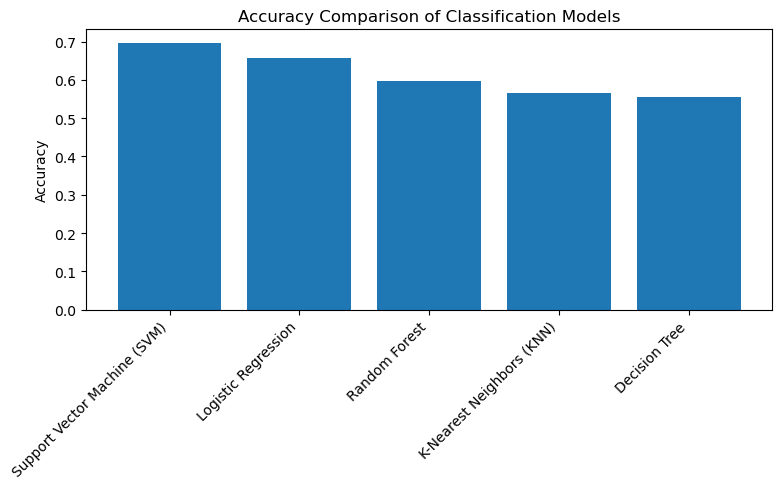

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(classification_results_df["Model"], classification_results_df["Accuracy"])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.tight_layout()
plt.show()

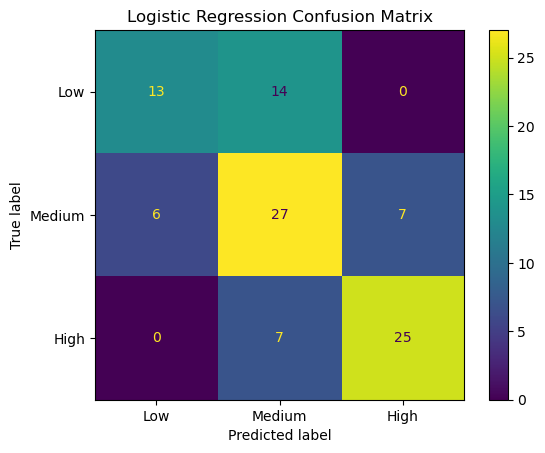

In [35]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train_class)
y_pred_log = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test_class, y_pred_log, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [36]:
cluster_features = [
    'Daily_Screen_Time(hrs)',
    'Sleep_Quality(1-10)',
    'Stress_Level(1-10)',
    'Days_Without_Social_Media',
    'Exercise_Frequency(week)',
    'Happiness_Index(1-10)'
]

X_cluster = df_clean[cluster_features]

In [37]:
scaler_cluster = StandardScaler()
Z = scaler_cluster.fit_transform(X_cluster)

In [38]:
inertia_values = []
silhouette_values = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(Z, labels))

cluster_metrics = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values,
    "silhouette": silhouette_values
})

cluster_metrics

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

,k,inertia,silhouette
0,2,1938.003947,0.282921
1,3,1679.504316,0.186174
2,4,1502.293166,0.184456
3,5,1345.815806,0.183689
4,6,1250.192164,0.176324


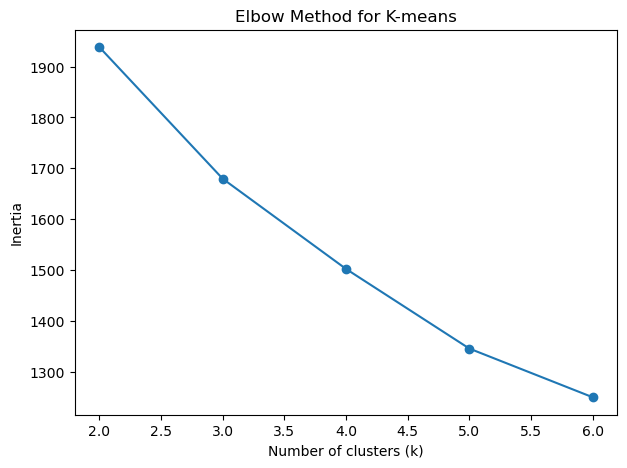

In [39]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-means")
plt.show()

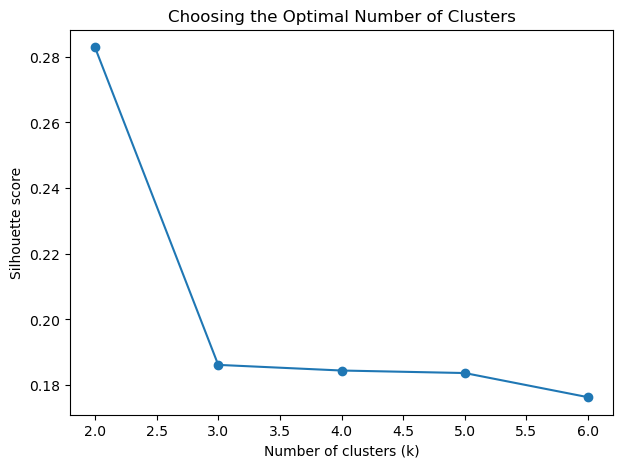

In [40]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_values, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Choosing the Optimal Number of Clusters")
plt.show()

In [41]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(Z)

df_clustered = df_clean.copy()
df_clustered["Cluster"] = cluster_labels

df_clustered.head()

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10),Cluster
0,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0,1
1,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0,0
2,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0,2
3,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0,0
4,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0,0


In [42]:
cluster_summary = df_clustered.groupby("Cluster")[cluster_features].mean()
cluster_sizes = df_clustered["Cluster"].value_counts().sort_index()

cluster_summary.insert(0, "Size", cluster_sizes.values)
cluster_summary

,Size,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
Cluster,,,,,,,
0,198,5.824242,6.040404,6.818182,3.479798,2.373737,8.323232
1,174,3.839655,7.747126,5.212644,3.195402,2.517241,9.764368
2,123,7.424390,4.699187,8.284553,2.520325,2.414634,6.520325


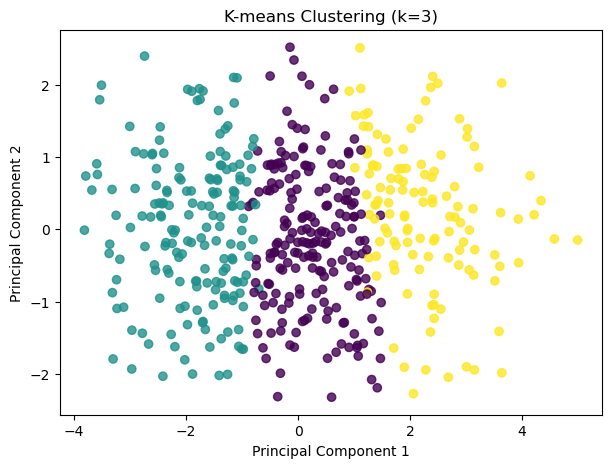

In [43]:
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(7, 5))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], c=cluster_labels, alpha=0.8)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-means Clustering (k=3)")
plt.show()

In [44]:
print("Cluster 0 - Moderate group: improve gradually with lower screen time, better sleep, and more consistent exercise.")
print("Cluster 1 - Healthiest group: maintain and reinforce balanced habits.")
print("Cluster 2 - High-risk group: focus on digital detox, stress reduction, and wellbeing support.")

Cluster 0 - Moderate group: improve gradually with lower screen time, better sleep, and more consistent exercise.
Cluster 1 - Healthiest group: maintain and reinforce balanced habits.
Cluster 2 - High-risk group: focus on digital detox, stress reduction, and wellbeing support.


In [45]:
df_clean.to_csv("Cleaned_Mental_Health_Dataset.csv", index=False)
print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


In [46]:
df_encoded.to_csv("Encoded_Mental_Health_Dataset.csv", index=False)
print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.
